# 2.1 — Базовые модели (MLP, GRU, TCN)

**Папка 2 «Обучение моделей», подноутбук 1.** Для каждой базовой модели выполняется
**подбор гиперпараметров перебором по сетке (grid search)** с богатой историей (все метрики
по каждой конфигурации). Метрика отбора выбирается явно. Лучшая комбинация сохраняется в
`models/<имя>/hyperparams.json`, после чего финальное обучение **читает этот JSON** и обучает
модель «начисто» с отслеживанием метрик. Рисунки и таблицы — на английском.

## Окружение и данные

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "dataset"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset, train_model
from liquefaction_ai.training import grid_search, write_hyperparams, read_hyperparams, save_trained_model
from liquefaction_ai.evaluation import METRICS, english_metric_table, metrics_catalog, subsample_split
from liquefaction_ai.viz import grid_search_dashboard, training_dashboard, lines

population, config = load_population_artifact(DATA_DIR)
from liquefaction_ai import resolve_device, configure_performance, describe_device
device = configure_performance(resolve_device())
print("device:", describe_device(device))
benchmark = prepare_benchmark_dataset(population, config, device)
static_dim = benchmark["train"]["static"].shape[1]
prefix_dim = benchmark["train"]["prefix_summary"].shape[1]
seq_dim = benchmark["train"]["seq_in"].shape[-1]

# Grid search выполняется на компактной подвыборке (для ранжирования гиперпараметров).
gs_train = subsample_split(benchmark["train"], 2000, config.seed)
gs_val = subsample_split(benchmark["val"], 600, config.seed + 1)


def show_grid_dashboard(res, grid, score, metric_keys, fig_id):
    """Построить дашборд grid search: по Y — метрики, по X — текст конфигурации."""
    info = METRICS[score]
    labels = {k: f"{METRICS[k].name} ({METRICS[k].units})" for k in metric_keys}
    fmts = {k: METRICS[k].fmt for k in metric_keys}
    return grid_search_dashboard(res, metric_keys, list(grid.keys()), score,
                                 metric_labels=labels, metric_fmts=fmts,
                                 lower_is_better=info.lower_is_better, target=info.target,
                                 save=SAVE_FIGS, fig_id=fig_id)

print("device:", device, "| dims static/prefix/seq:", static_dim, prefix_dim, seq_dim)
from liquefaction_ai.models import (GRUBaseline, LSTMBaseline, RiskMLP, TCNBaseline,
                                    TransformerBaseline, FTTransformer, CatBoostBaseline,
                                    PINNBaseline, DeepStateBaseline, RealNVPFlow, NeuralSplineFlow)

device: mps (Apple Metal)
device: mps | dims static/prefix/seq: 38 6 5


## Каталог метрик

Все метрики качества определены с подробными описаниями в `liquefaction_ai.evaluation.metrics`
(`METRICS`) и импортируются в ноутбук. **Метрику отбора лучших гиперпараметров можно выбрать**
через переменную `SELECTION_METRIC` ниже.

In [2]:
display(metrics_catalog())

,Metric,Name,Units,Direction,Description
0,val_loss,Validation loss,–,lower is better,Mean validation value of the model's training ...
1,Traj_RMSE,Trajectory RMSE,–,lower is better,Root-mean-square error of the predicted pore-p...
2,Traj_MAE,Trajectory MAE,–,lower is better,Mean absolute error of the predicted PPR(N) tr...
3,Traj_MSE,Trajectory MSE,–,lower is better,Mean squared error of the predicted PPR(N) tra...
4,N_liq_MAE,MAE of N_liq,cycles,lower is better,Censored mean absolute error of the predicted ...
5,N_liq_Curve_Coherence_MAE,N_liq/curve coherence MAE,cycles,lower is better,Mean absolute gap between the reported N_liq a...
6,Risk_Curve_Coherence_Rate,Risk/curve coherence rate,–,higher is better,Fraction of samples for which risk>=0.5 agrees...
7,AUROC,AUROC,–,higher is better,Area under the ROC curve for liquefaction-risk...
8,AUPRC,AUPRC,–,higher is better,Area under the precision–recall curve; classif...
9,Brier,Brier score,–,lower is better,Mean squared error of the predicted liquefacti...


## Шаг 1. Grid search, история по всем метрикам и сохранение гиперпараметров

Для каждой модели задана своя метрика отбора `score` (можно менять). Дашборд показывает
все метрики по каждой конфигурации; лучшая по метрике отбора подсвечена.

[MLP-Risk] selection metric = Brier | best = {'hidden_dim': 64}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR,CRR_Onset_Coherence_MAE,Traj_RMSE_continuation_siteMacro,N_liq_logMAE_siteMacro,N_sites_test
0,64,0.4944,526.5280,816.7068,0.8372,1.1774,118.0,1.0,1.0822,540.6622,...,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,0.8336,2.0
1,128,0.6493,636.5606,903.2000,0.9932,1.3225,118.0,1.0,1.2660,621.5850,...,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,0.9923,2.0


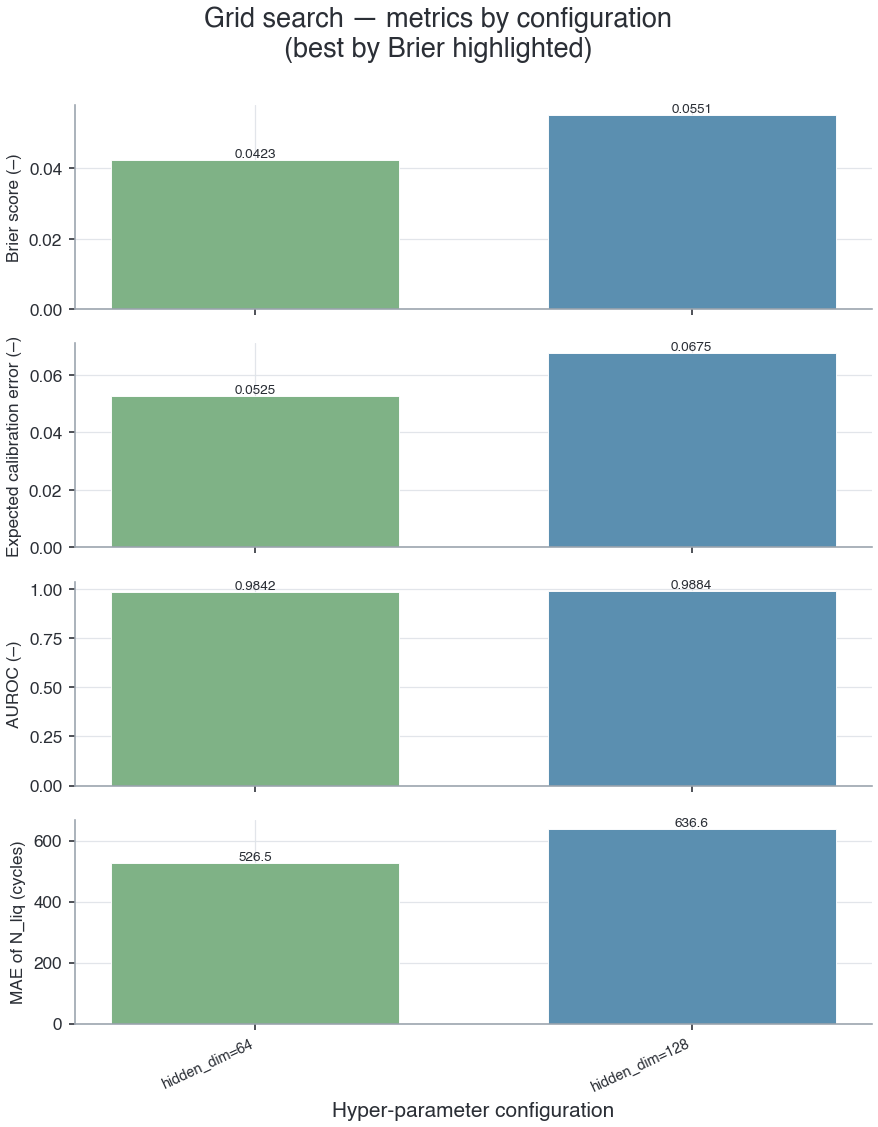

[GRU] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR,CRR_Onset_Coherence_MAE,Traj_RMSE_continuation_siteMacro,N_liq_logMAE_siteMacro,N_sites_test
0,96,-1.6563,566.7437,827.2123,0.9291,1.2883,118.0,1.0,1.1904,551.8916,...,-0.7462,0.0550,NaN,0.0,0.0,0.0,NaN,0.0878,0.9104,2.0
1,64,-1.1093,585.0479,809.4280,0.8575,1.0621,118.0,1.0,0.9593,313.1351,...,-0.5313,0.0749,NaN,0.0,0.0,0.0,NaN,0.1206,0.8492,2.0


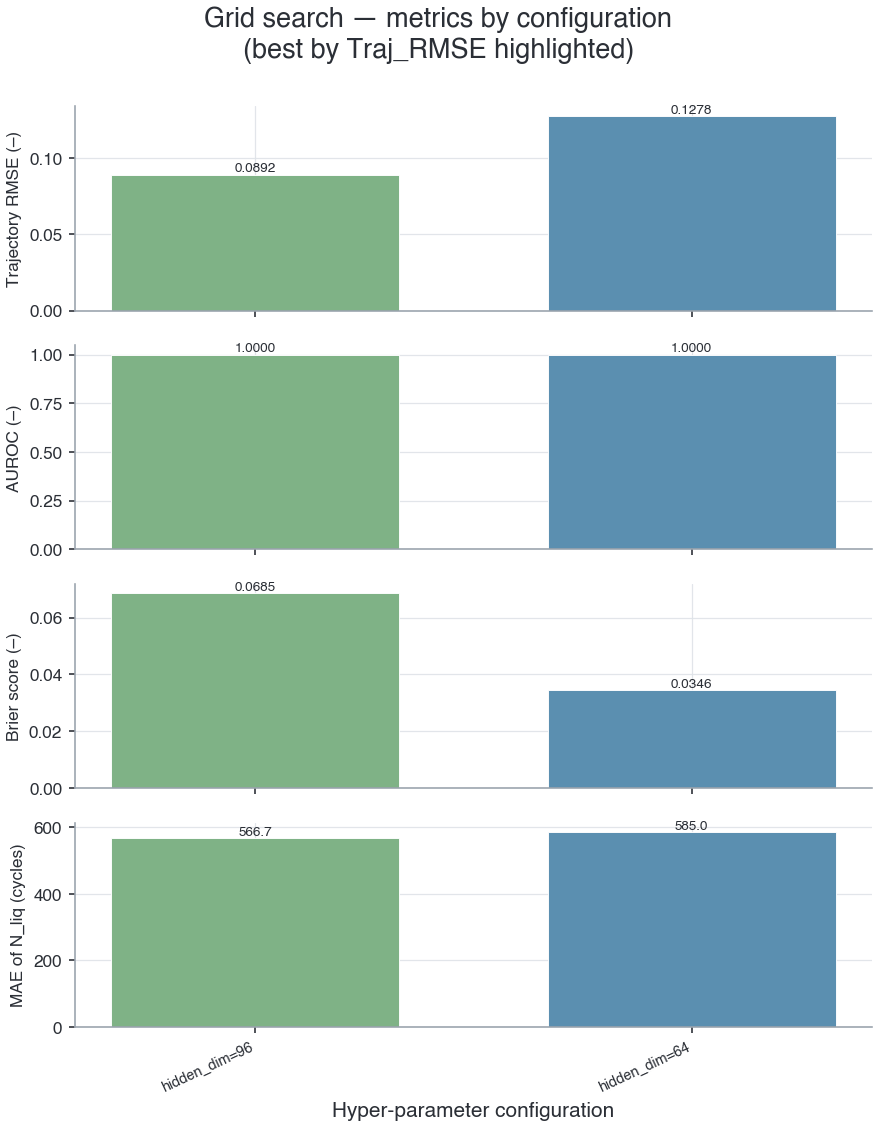

[TCN] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR,CRR_Onset_Coherence_MAE,Traj_RMSE_continuation_siteMacro,N_liq_logMAE_siteMacro,N_sites_test
0,96,-1.9541,412.2224,692.8003,0.8115,1.1362,118.0,1.0,1.0806,471.4318,...,-0.9463,0.0533,NaN,0.0,0.0,0.0,NaN,0.0821,0.7526,2.0
1,64,-1.9352,382.6298,674.1490,0.7710,1.1128,118.0,1.0,1.0216,421.5724,...,-0.9856,0.0532,NaN,0.0,0.0,0.0,NaN,0.0841,0.7251,2.0


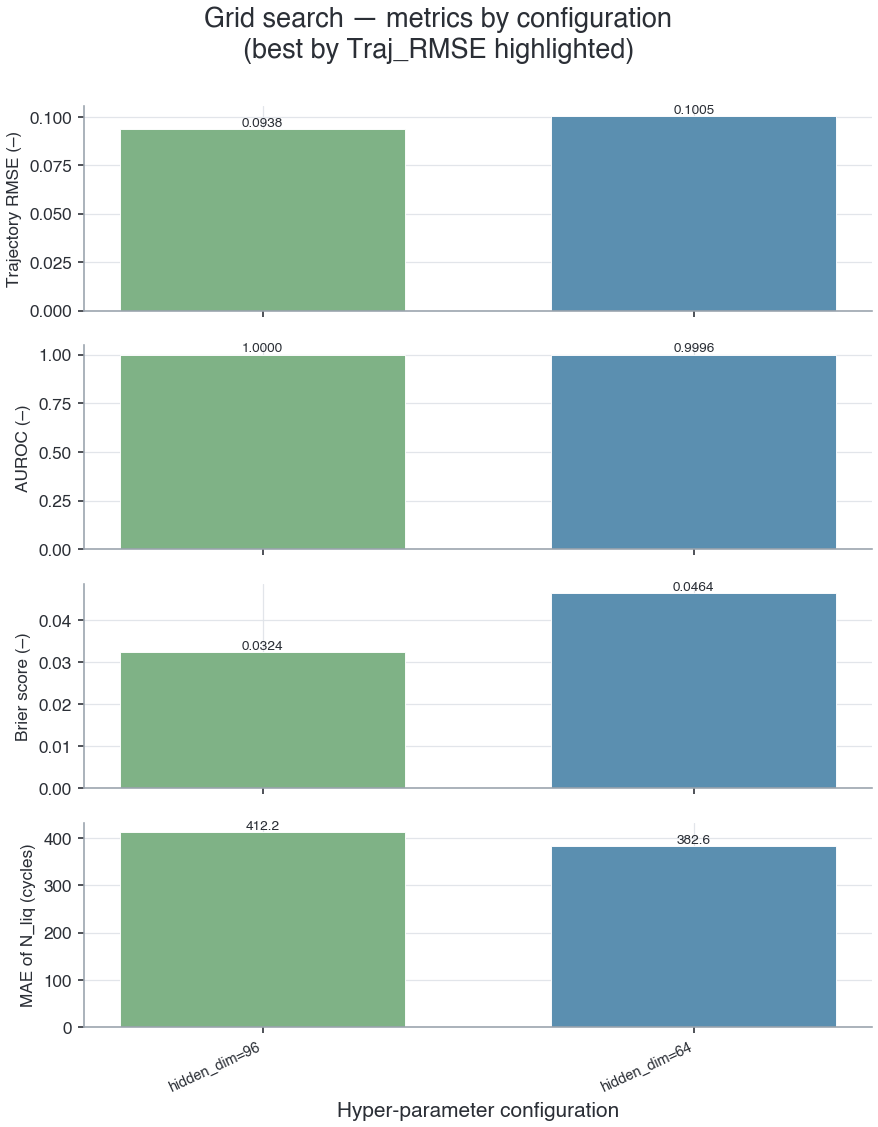

[LSTM] selection metric = Traj_RMSE | best = {'hidden_dim': 64}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR,CRR_Onset_Coherence_MAE,Traj_RMSE_continuation_siteMacro,N_liq_logMAE_siteMacro,N_sites_test
0,64,-0.4860,552.2238,787.0195,0.811,0.9863,118.0,1.0,0.9170,304.6107,...,-0.4201,0.0853,NaN,0.0,0.0,0.0,NaN,0.1371,0.8110,2.0
1,96,1.4404,671.8168,1201.9832,0.750,0.9264,118.0,1.0,0.4852,79.5120,...,-0.3598,0.0972,NaN,0.0,0.0,0.0,NaN,0.1663,0.8123,2.0


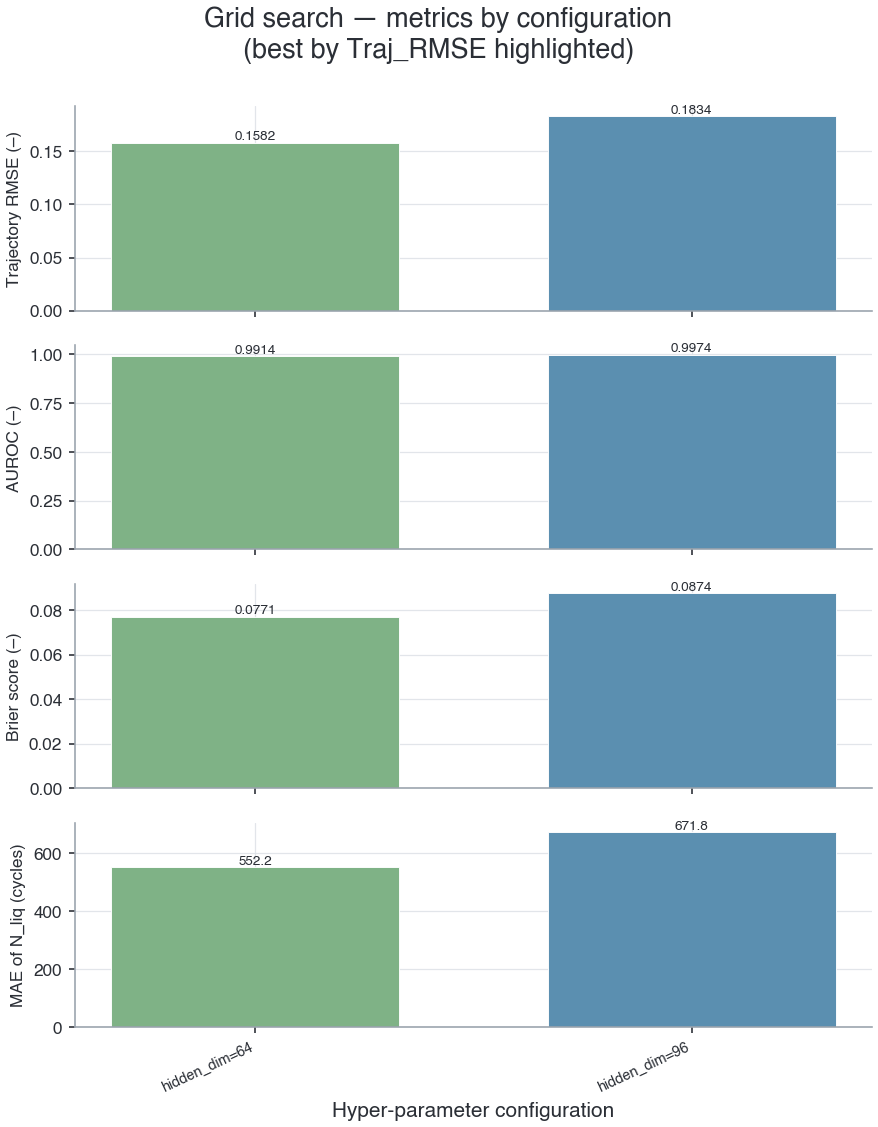

[Transformer] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR,CRR_Onset_Coherence_MAE,Traj_RMSE_continuation_siteMacro,N_liq_logMAE_siteMacro,N_sites_test
0,96,-2.1512,290.8426,498.9579,0.6178,0.8240,118.0,1.0,0.8033,273.8957,...,-1.1091,0.0438,NaN,0.0,0.0,0.0,NaN,0.0662,0.6098,2.0
1,64,-2.1809,326.7195,523.2767,0.4338,0.5947,118.0,1.0,0.4763,144.9919,...,-1.1653,0.0464,NaN,0.0,0.0,0.0,NaN,0.0715,0.4502,2.0


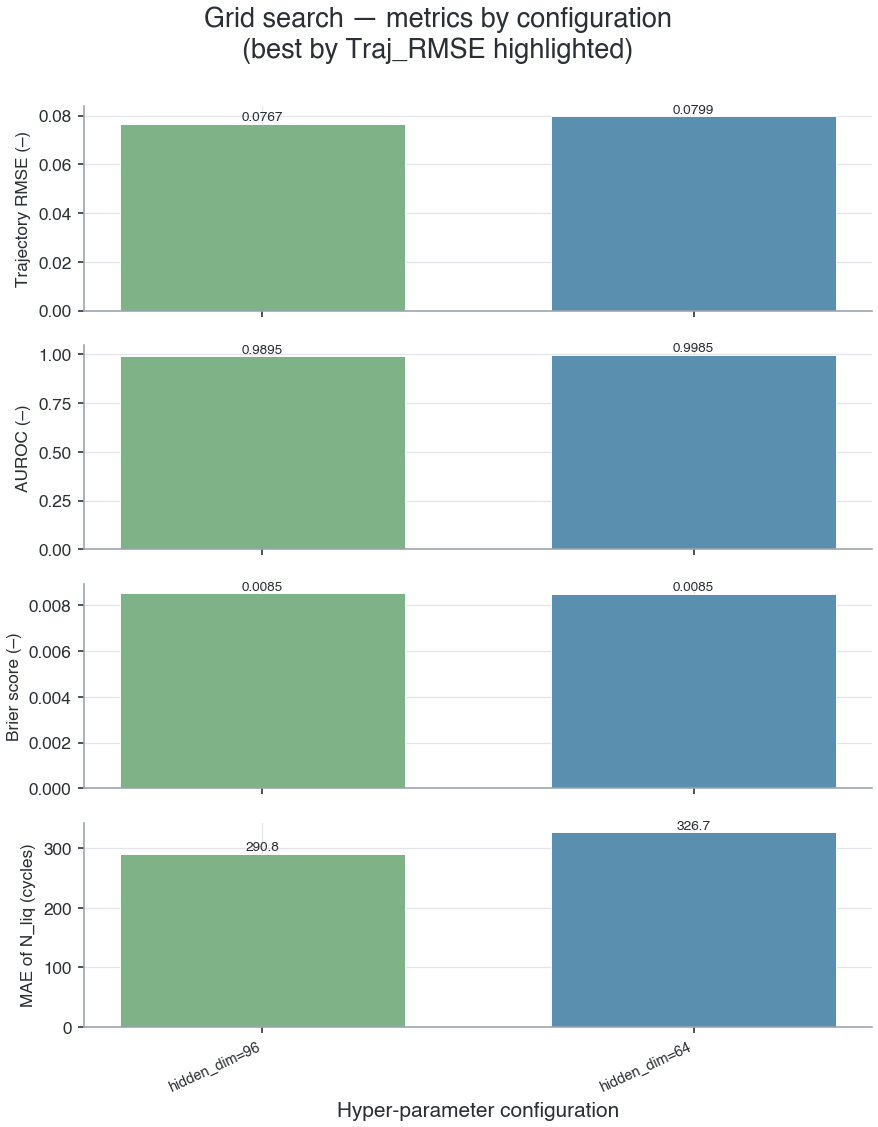

[FT-Transformer] selection metric = Brier | best = {'n_layers': 2}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR,CRR_Onset_Coherence_MAE,Traj_RMSE_continuation_siteMacro,N_liq_logMAE_siteMacro,N_sites_test
0,2,0.127,234.825,533.9641,0.4950,0.7969,118.0,1.0,0.6319,221.1913,...,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,0.4670,2.0
1,3,0.316,517.474,824.2822,0.6159,0.8350,118.0,1.0,0.6341,255.0674,...,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,0.6439,2.0


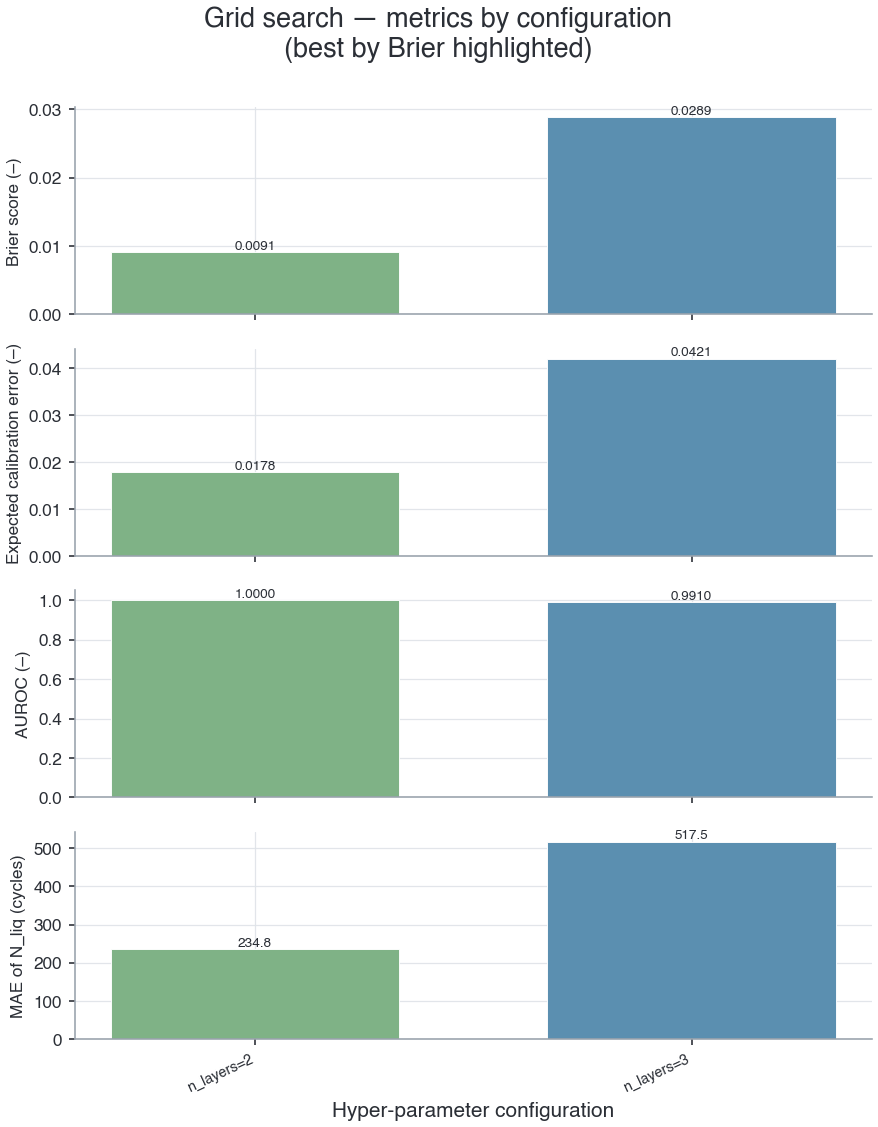

[PINN] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR,CRR_Onset_Coherence_MAE,Traj_RMSE_continuation_siteMacro,N_liq_logMAE_siteMacro,N_sites_test
0,96,-1.2615,721.3640,854.5790,1.3555,1.5590,118.0,1.0,1.7688,748.6379,...,-0.8085,0.0579,NaN,0.0,0.0,0.0,NaN,0.0913,1.2789,2.0
1,64,-1.0469,849.4532,946.9636,1.4842,1.6698,118.0,1.0,1.8932,811.3563,...,-0.5701,0.0665,NaN,0.0,0.0,0.0,NaN,0.1074,1.4094,2.0


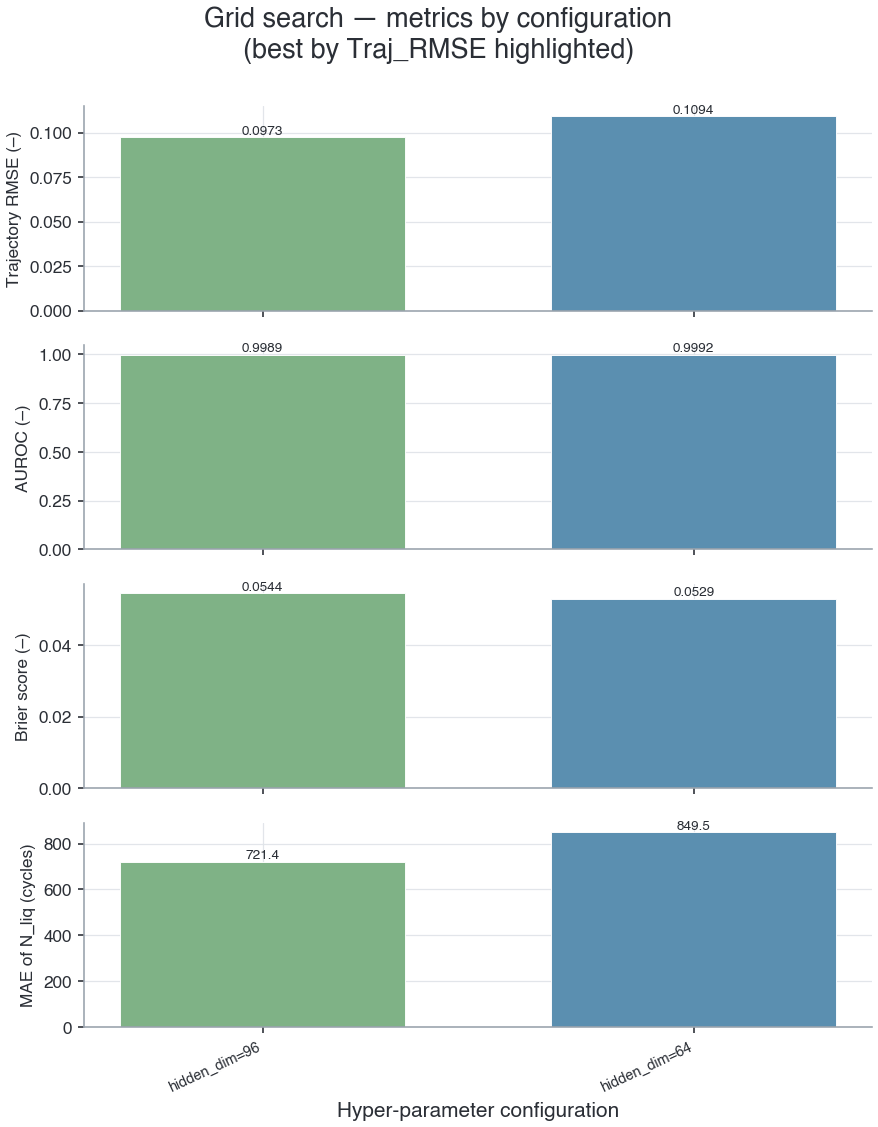

[DeepState] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR,CRR_Onset_Coherence_MAE,Traj_RMSE_continuation_siteMacro,N_liq_logMAE_siteMacro,N_sites_test
0,96,-0.8986,513.0303,755.6834,0.6823,0.9276,118.0,1.0,0.7756,315.0848,...,-0.3365,0.0661,NaN,0.0,0.0,0.0,NaN,0.0998,0.6906,2.0
1,64,-1.1593,551.8059,825.6973,0.6826,0.9424,118.0,1.0,0.7472,315.2130,...,-0.4311,0.0690,NaN,0.0,0.0,0.0,NaN,0.1062,0.6981,2.0


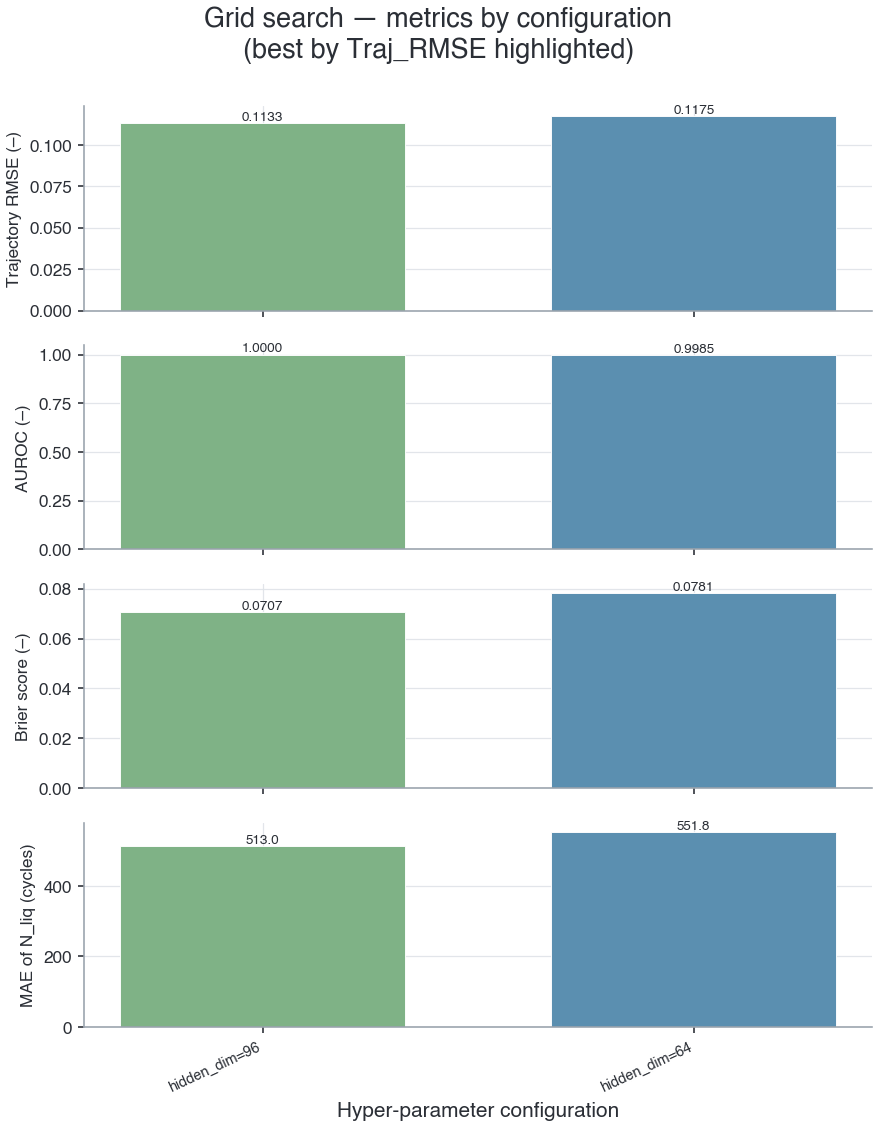

[RealNVP] selection metric = Traj_RMSE | best = {'n_layers': 4}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR,CRR_Onset_Coherence_MAE,Traj_RMSE_continuation_siteMacro,N_liq_logMAE_siteMacro,N_sites_test
0,4,0.4445,688.4270,883.4483,1.0744,1.2525,118.0,1.0,1.2647,527.5952,...,-0.5459,0.0690,NaN,0.0,0.0,0.0,NaN,0.1153,1.0616,2.0
1,6,0.1819,668.7557,916.4590,0.9880,1.1094,118.0,1.0,1.0572,356.0109,...,-0.1755,0.0767,NaN,0.0,0.0,0.0,NaN,0.1245,0.9935,2.0


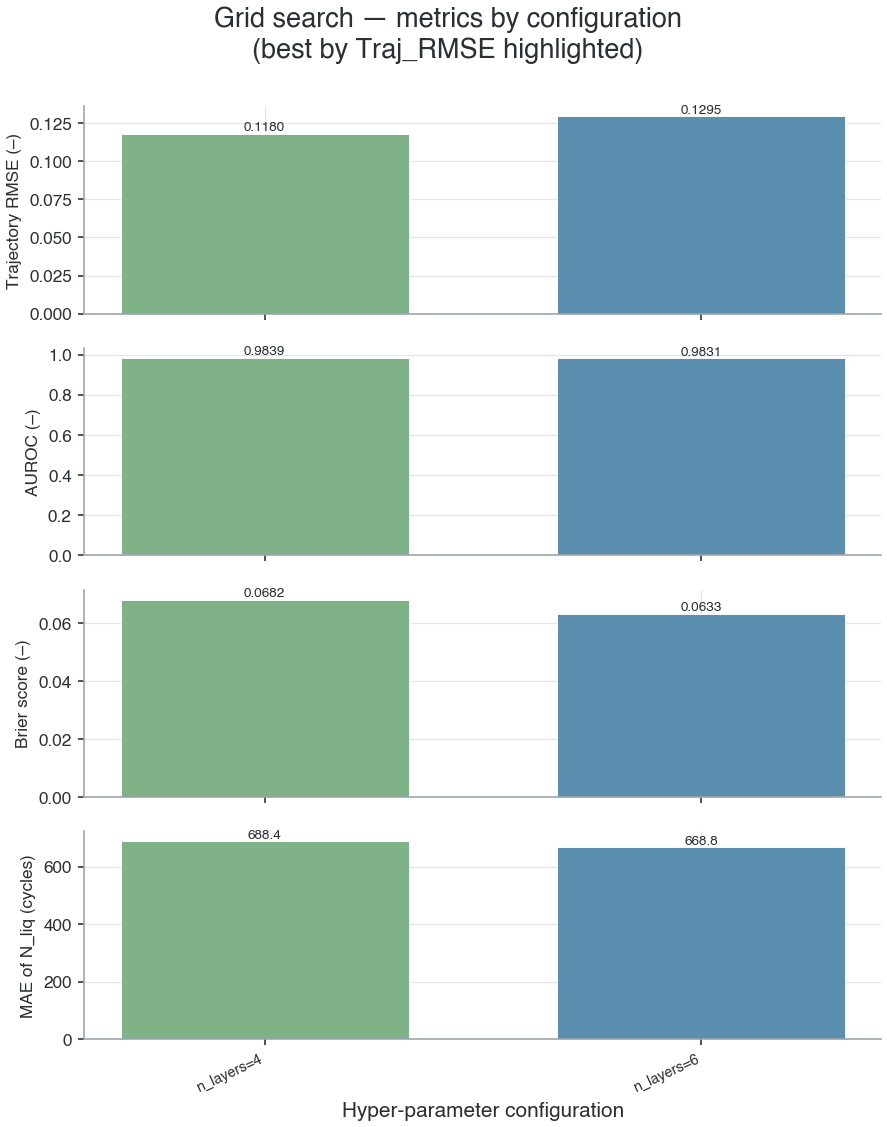

[Neural Spline Flow] selection metric = Traj_RMSE | best = {'n_layers': 4}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,N_liq_MAE_liq,...,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR,CRR_Onset_Coherence_MAE,Traj_RMSE_continuation_siteMacro,N_liq_logMAE_siteMacro,N_sites_test
0,4,10.689,595.1802,829.9773,0.8563,1.0371,118.0,1.0,0.9438,340.4691,...,-0.2713,0.0910,NaN,0.0,0.0,0.0,NaN,0.1520,0.8745,2.0
1,5,10.678,637.0765,886.1469,0.9185,1.0742,118.0,1.0,0.9885,348.8242,...,0.1032,0.0993,NaN,0.0,0.0,0.0,NaN,0.1638,0.9344,2.0


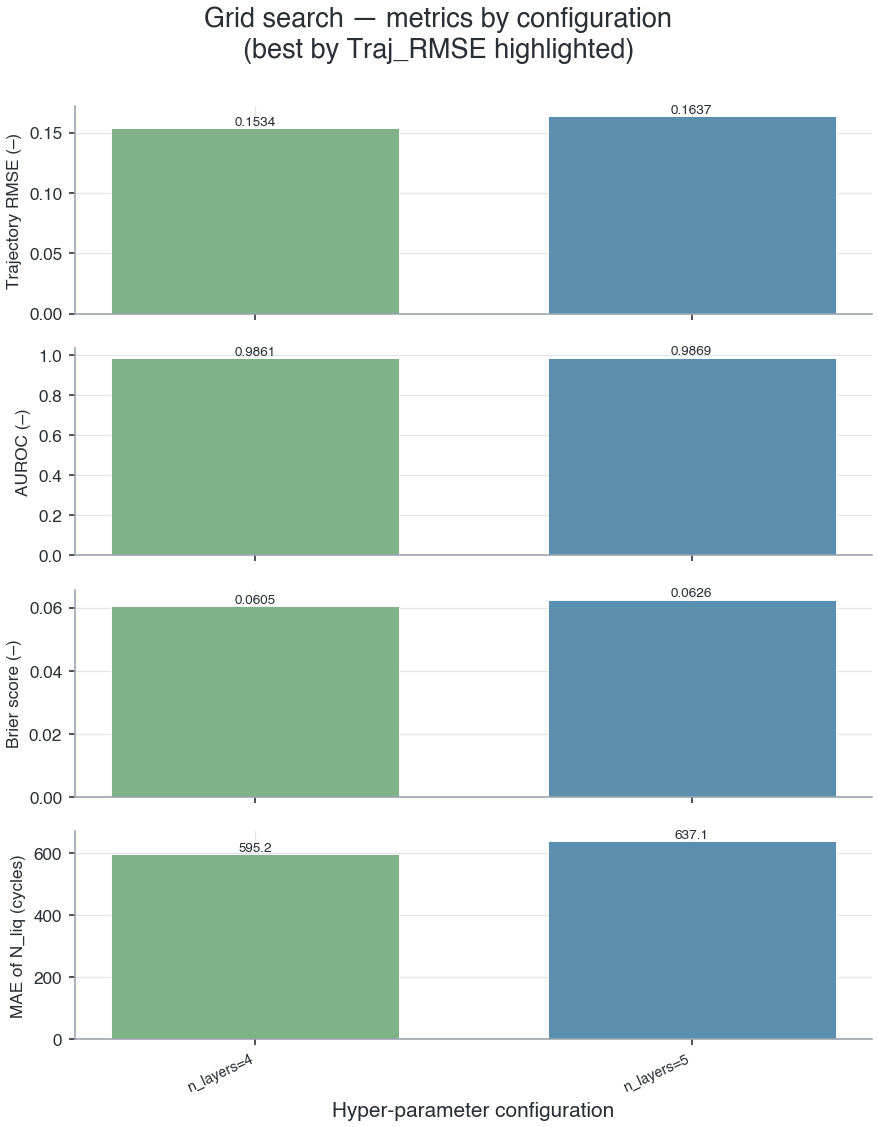

In [3]:
base_specs = {
    "mlp_risk": dict(display="MLP-Risk", cls=RiskMLP,
                     fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim),
                     grid={"hidden_dim": [64, 128]}, score="Brier",
                     metrics=["Brier", "ECE", "AUROC", "N_liq_MAE"]),
    "gru": dict(display="GRU", cls=GRUBaseline,
                fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "tcn": dict(display="TCN", cls=TCNBaseline,
                fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "lstm": dict(display="LSTM", cls=LSTMBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "transformer": dict(display="Transformer", cls=TransformerBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim, seq_len=config.seq_len),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "ft_transformer": dict(display="FT-Transformer", cls=FTTransformer,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim),
                 grid={"n_layers": [2, 3]}, score="Brier",
                 metrics=["Brier", "ECE", "AUROC", "N_liq_MAE"]),
    "pinn": dict(display="PINN", cls=PINNBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "deepstate": dict(display="DeepState", cls=DeepStateBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "realnvp": dict(display="RealNVP", cls=RealNVPFlow,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_len=config.seq_len),
                 grid={"n_layers": [4, 6]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "nsf": dict(display="Neural Spline Flow", cls=NeuralSplineFlow,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_len=config.seq_len),
                 grid={"n_layers": [4, 5]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
}

for name, spec in base_specs.items():
    cls, fixed, grid, score = spec["cls"], spec["fixed"], spec["grid"], spec["score"]
    res, best = grid_search(lambda p, cls=cls, fixed=fixed: cls(**fixed, **p),
                            grid, gs_train, gs_val, config, device, search_epochs=config.grid_search_epochs, score_metric=score)
    write_hyperparams(MODELS_DIR, name, {"model_type": cls.__name__, "display_name": spec["display"],
                      "model_kwargs": {**fixed, **best}, "search": {"grid": grid, "score_metric": score, "best": best}})
    print(f"[{spec['display']}] selection metric = {score} | best = {best}")
    display(english_metric_table(res).round(4))
    show_grid_dashboard(res, grid, score, spec["metrics"], f"2_1_grid_search_{name}").show()

## Шаг 2. Финальное обучение по сохранённым гиперпараметрам

In [4]:
# Реестр классов всех baseline (имя класса -> класс) и число эпох по семействам
CLS = {RiskMLP.__name__: RiskMLP, GRUBaseline.__name__: GRUBaseline, TCNBaseline.__name__: TCNBaseline,
       LSTMBaseline.__name__: LSTMBaseline, TransformerBaseline.__name__: TransformerBaseline,
       FTTransformer.__name__: FTTransformer, PINNBaseline.__name__: PINNBaseline,
       DeepStateBaseline.__name__: DeepStateBaseline, RealNVPFlow.__name__: RealNVPFlow,
       NeuralSplineFlow.__name__: NeuralSplineFlow}
# PINN — физически-структурированная (больше эпох); остальные baseline — config.baseline_epochs
epoch_map = {name: (config.publication_physics_epochs if name == "pinn" else config.publication_baseline_epochs) for name in base_specs}
histories = {}
for name in base_specs:
    hp = read_hyperparams(MODELS_DIR, name)
    model = CLS[hp["model_type"]](**hp["model_kwargs"]).to(device)
    epochs = epoch_map[name]
    model, history = train_model(model, benchmark["train"], benchmark["val"], epochs=epochs,
                                 model_name=hp["display_name"], config=config, device=device, track_metrics=True)
    save_trained_model(model, MODELS_DIR, name, {**hp, "epochs": len(history), "learning_rate": config.learning_rate,
                       "weight_decay": config.weight_decay, "batch_size": config.batch_size, "seed": config.seed}, history)
    histories[hp["display_name"]] = history
    print("saved:", MODELS_DIR / name)

[MLP-Risk] эпоха 01 | обучение=0.8210 | валидация=0.5728 | val_AUROC=0.815 | stale=0/25
[MLP-Risk] эпоха 02 | обучение=0.4839 | валидация=0.3968 | val_AUROC=0.980 | stale=0/25
[MLP-Risk] эпоха 03 | обучение=0.3151 | валидация=0.2704 | val_AUROC=0.980 | stale=0/25
[MLP-Risk] эпоха 04 | обучение=0.2121 | валидация=0.2146 | val_AUROC=0.979 | stale=0/25
[MLP-Risk] эпоха 05 | обучение=0.1672 | валидация=0.1847 | val_AUROC=0.980 | stale=0/25
[MLP-Risk] эпоха 06 | обучение=0.1232 | валидация=0.1618 | val_AUROC=0.980 | stale=0/25
[MLP-Risk] эпоха 07 | обучение=0.0846 | валидация=0.1531 | val_AUROC=0.981 | stale=0/25
[MLP-Risk] эпоха 08 | обучение=0.0782 | валидация=0.1732 | val_AUROC=0.983 | stale=1/25
[MLP-Risk] эпоха 09 | обучение=0.0522 | валидация=0.2094 | val_AUROC=0.982 | stale=2/25
[MLP-Risk] эпоха 10 | обучение=0.0351 | валидация=0.2433 | val_AUROC=0.982 | stale=3/25
[MLP-Risk] эпоха 11 | обучение=0.0258 | валидация=0.2376 | val_AUROC=0.982 | stale=4/25
[MLP-Risk] эпоха 12 | обучение=0

## Кривые обучения с метриками

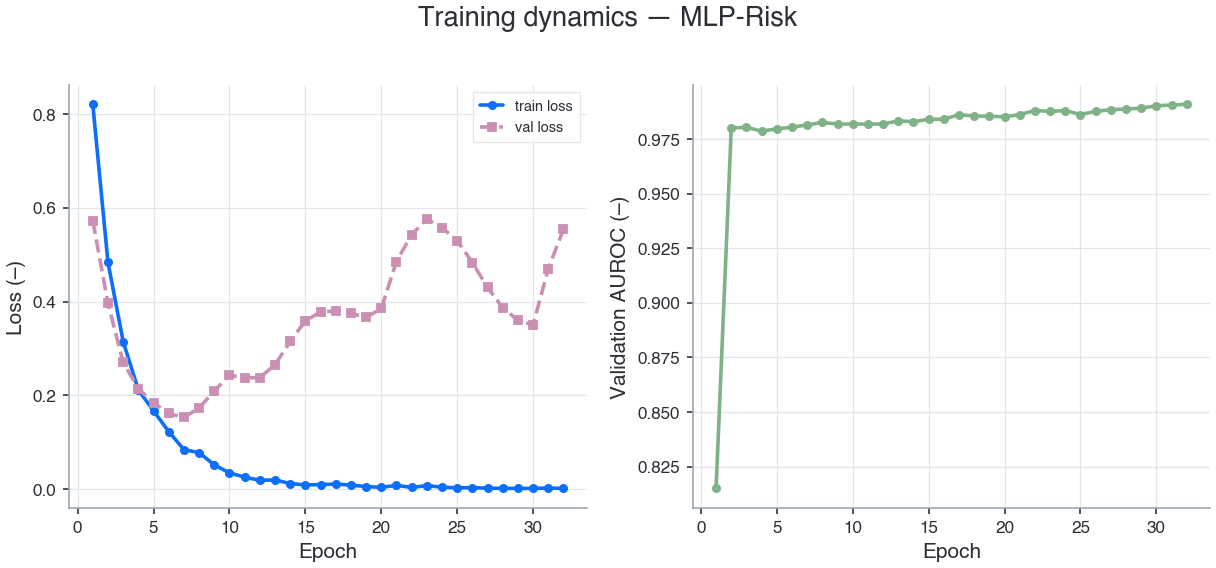

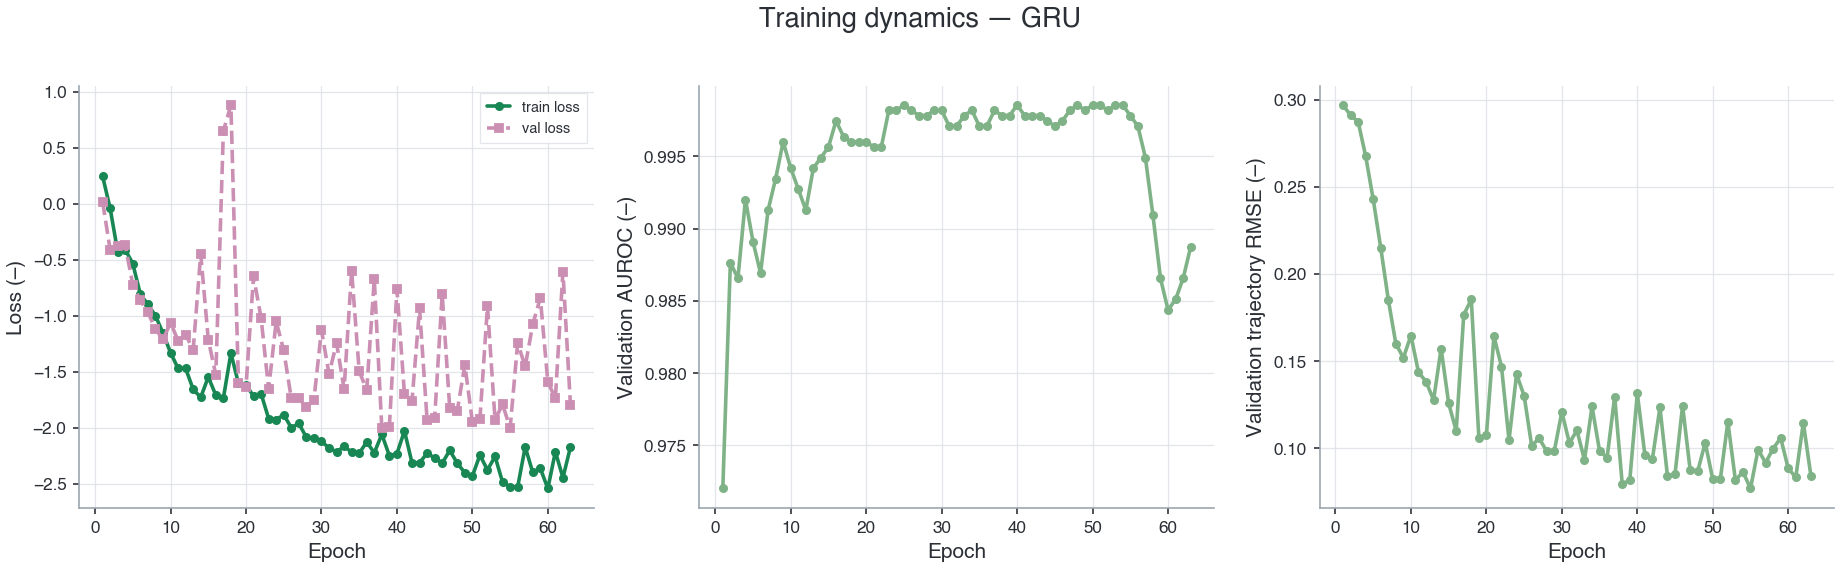

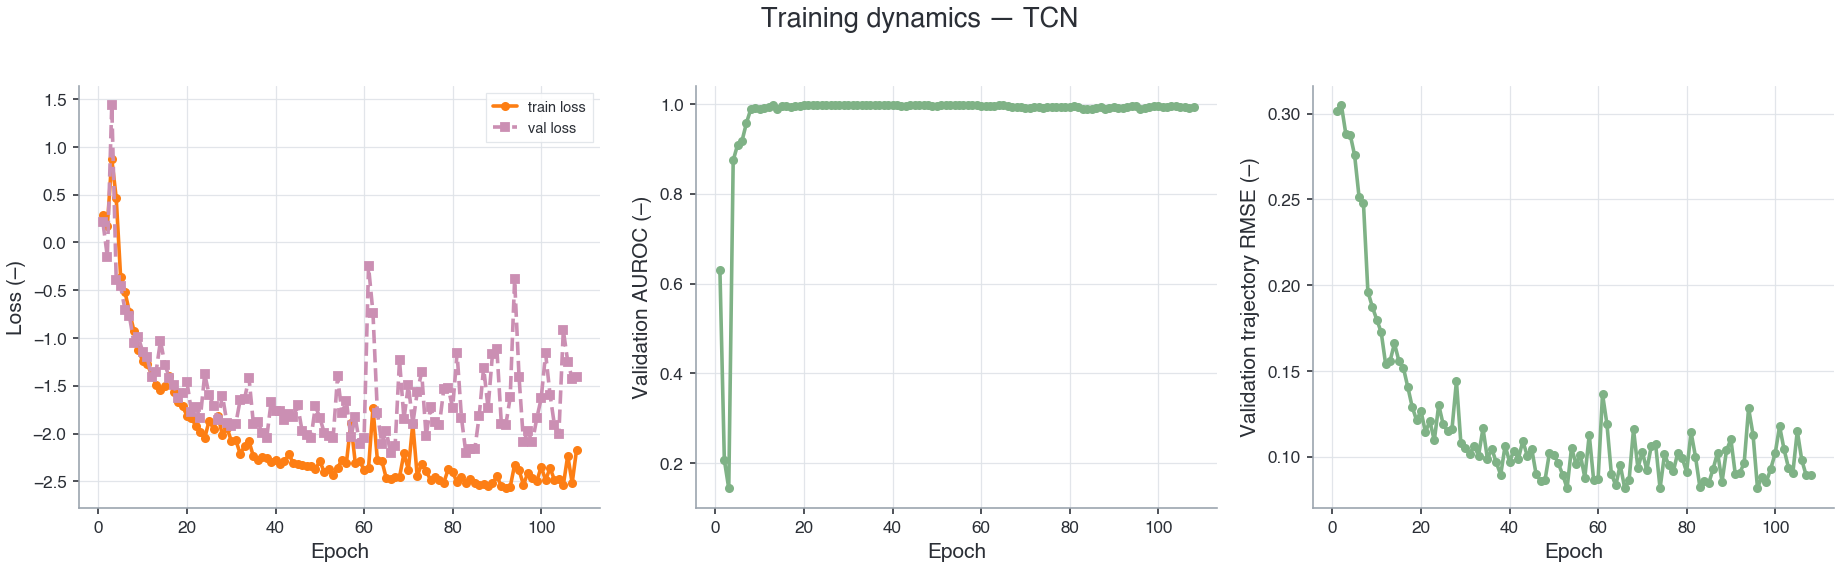

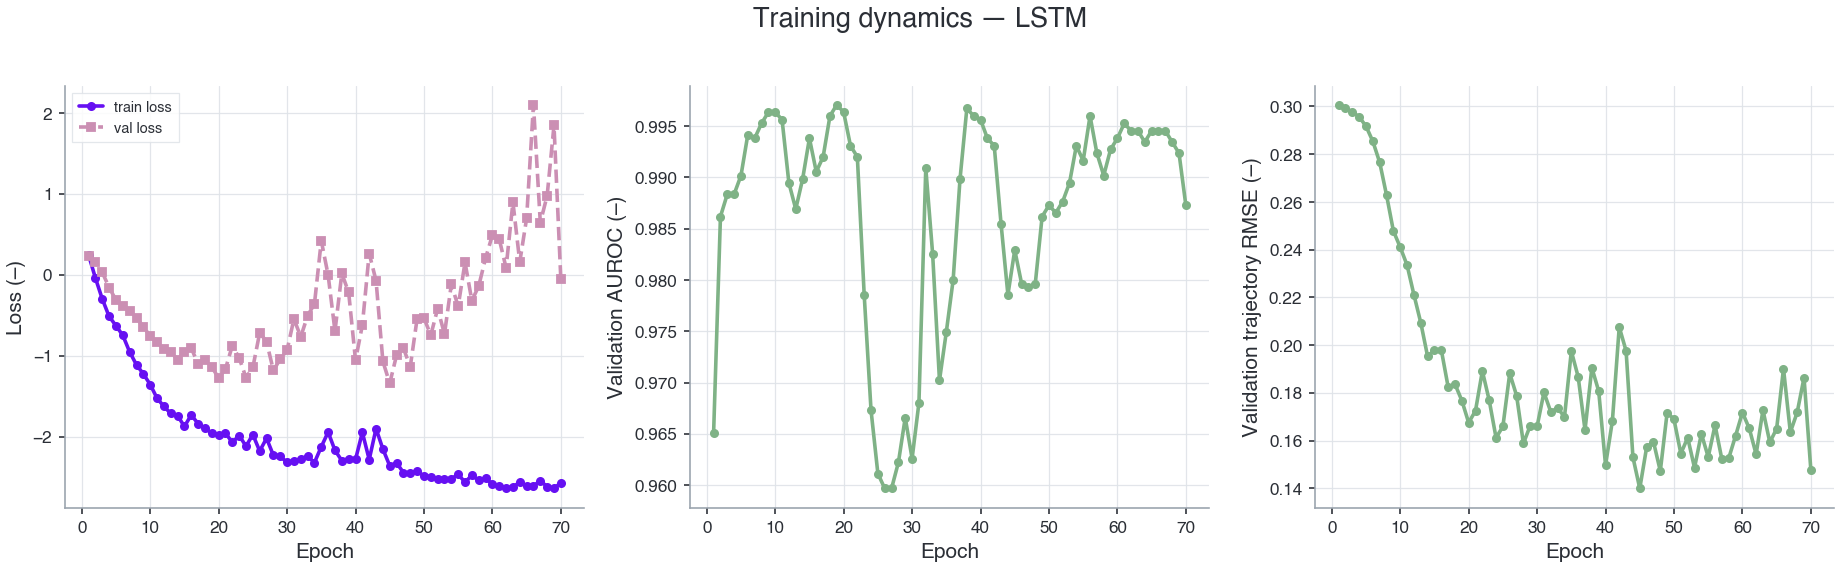

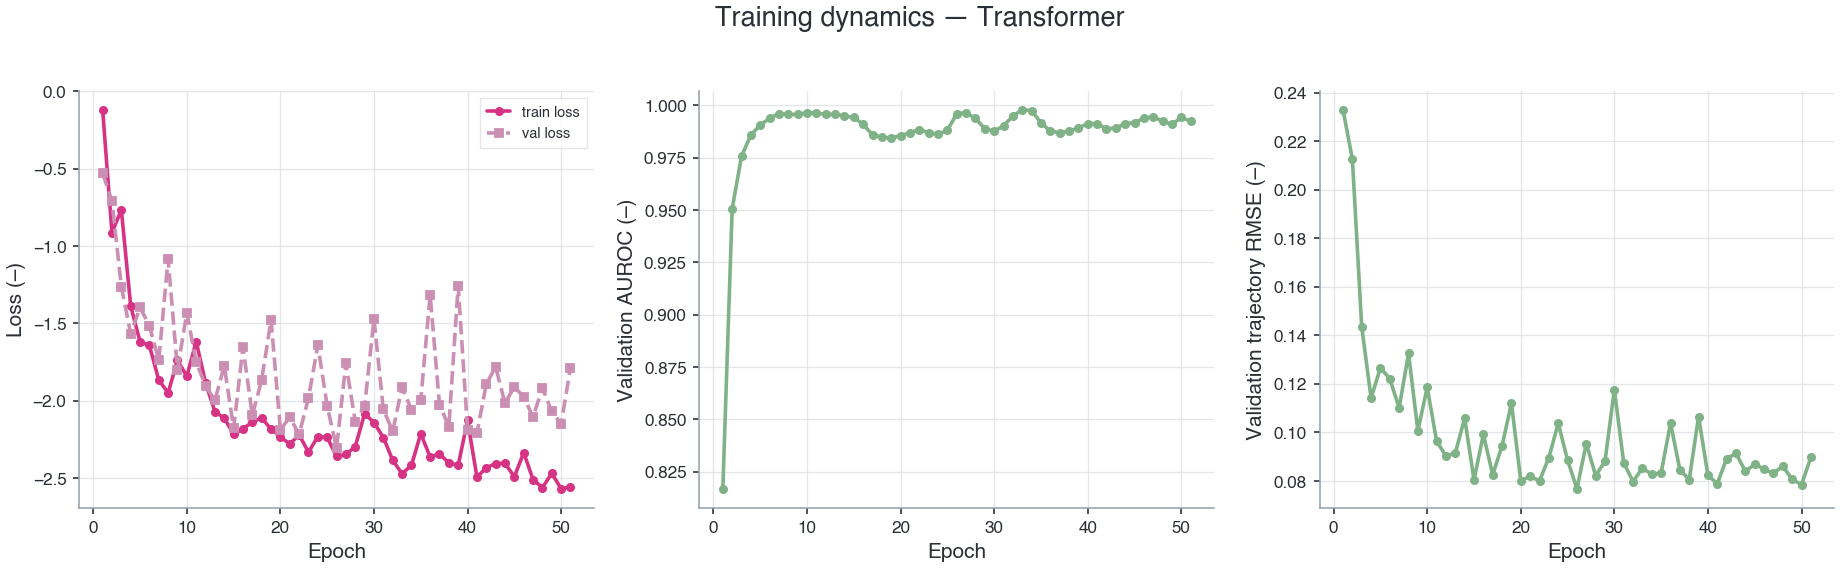

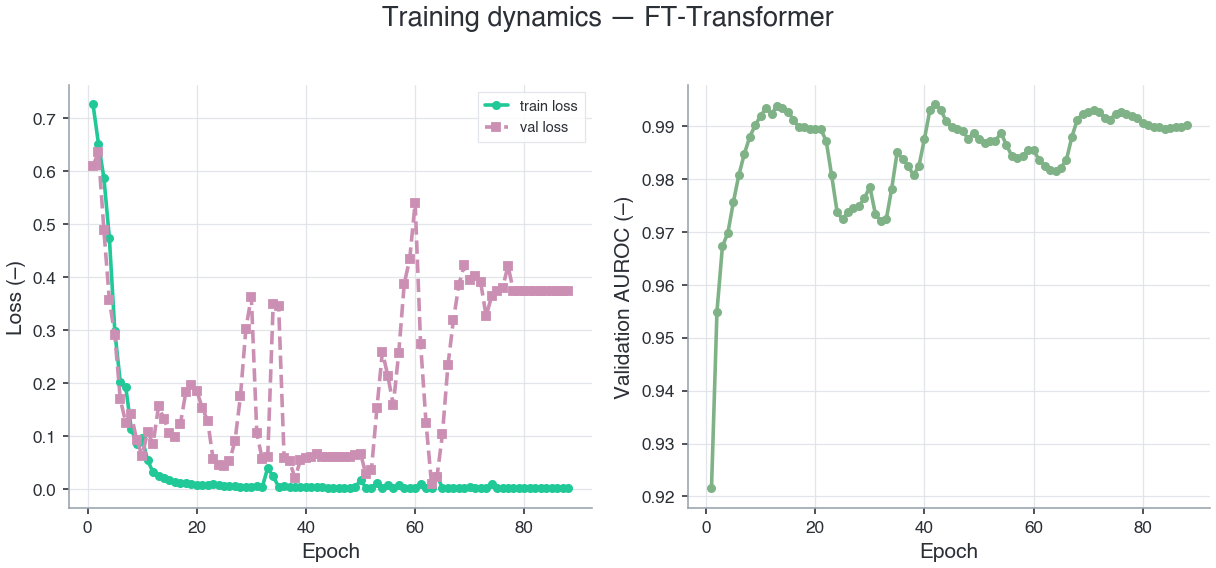

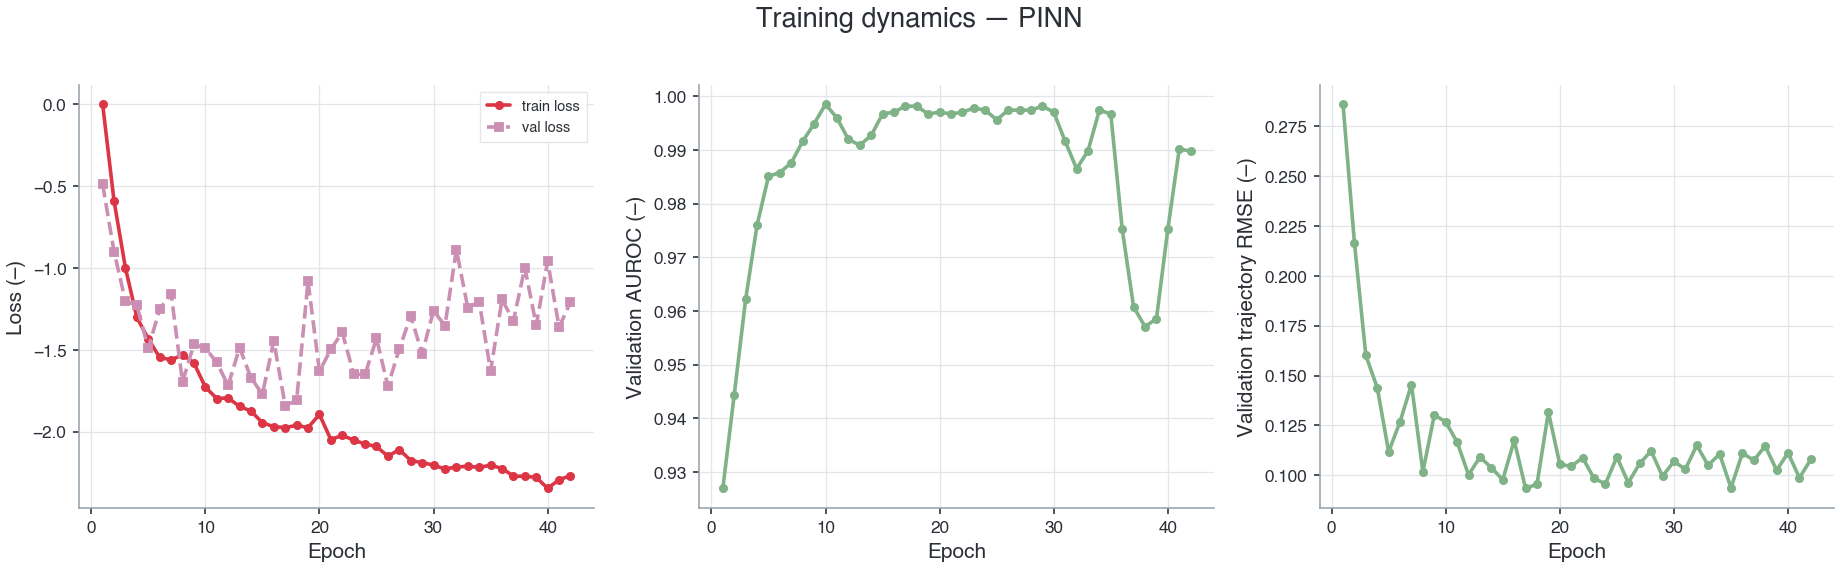

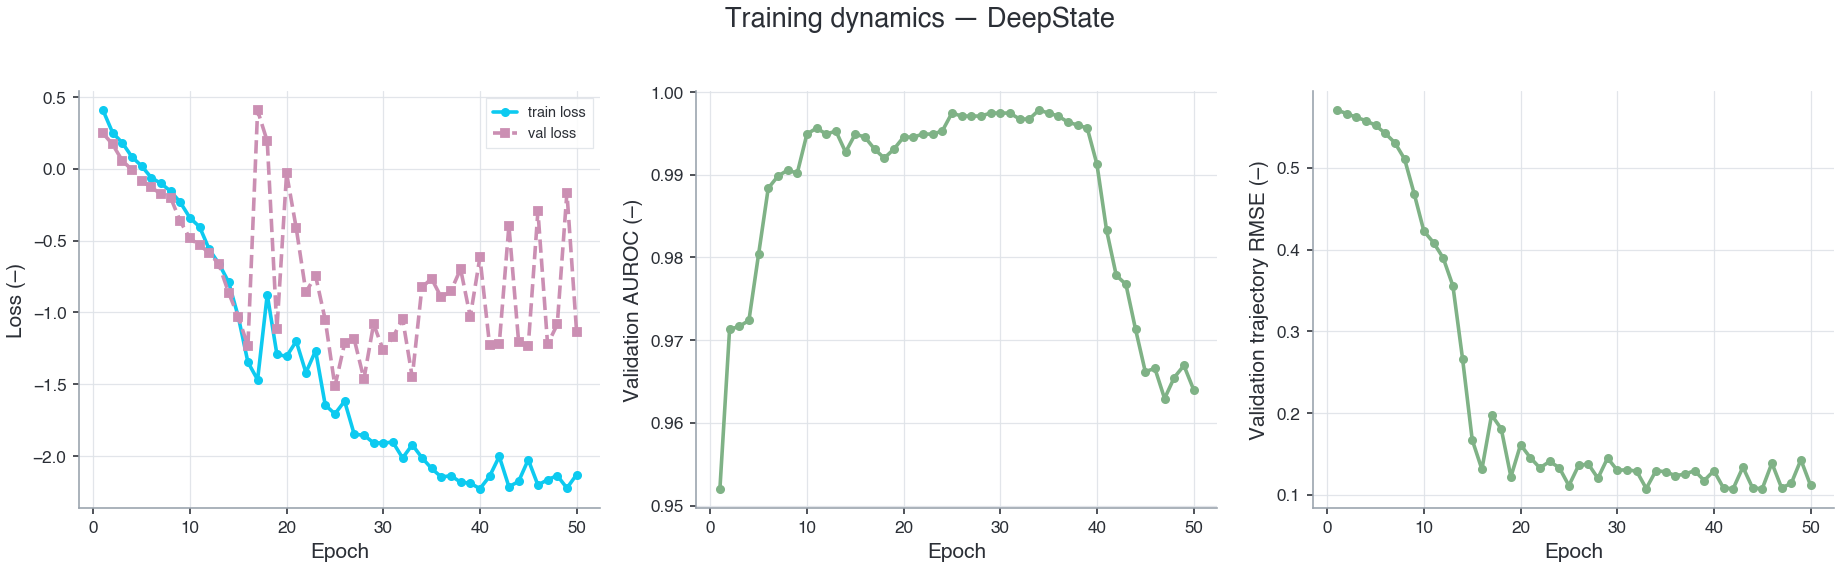

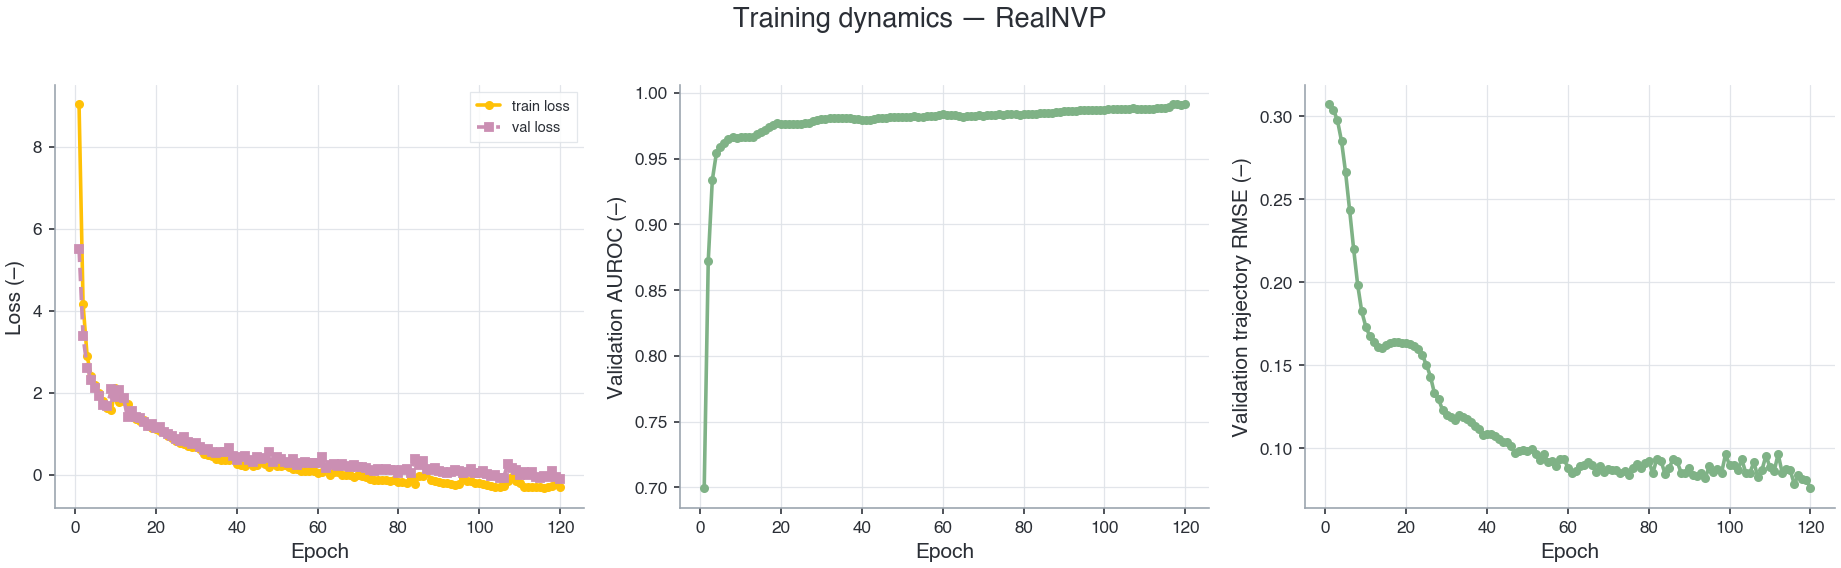

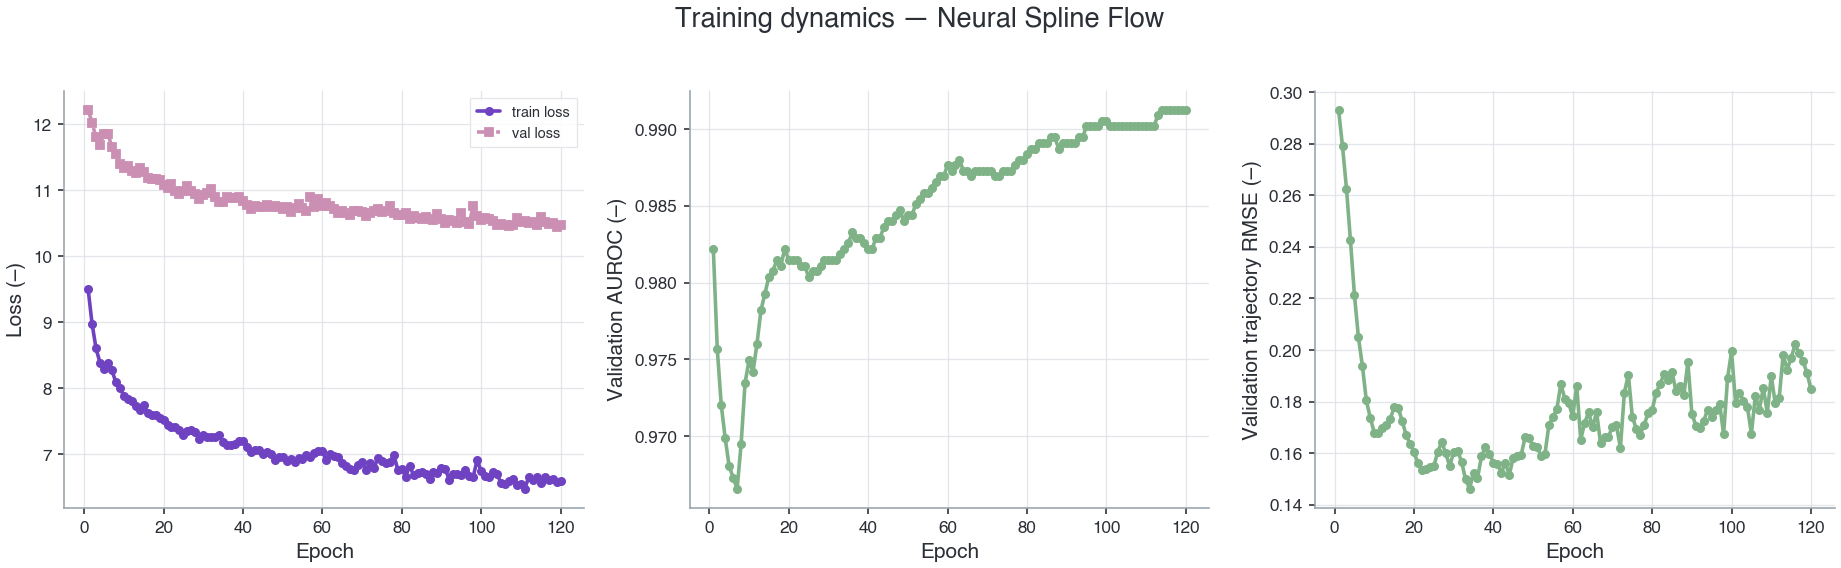

In [5]:
palette = ["#0b6efd", "#198754", "#fd7e14", "#6610f2", "#d63384", "#20c997", "#dc3545", "#0dcaf0", "#ffc107", "#6f42c1"]
colors = {disp: palette[i % len(palette)] for i, disp in enumerate(histories)}
for disp, hist in histories.items():
    training_dashboard(hist, title=f"Training dynamics — {disp}", model_color=colors[disp],
                       save=SAVE_FIGS, fig_id=f"2_1_training_{disp.lower().replace('-', '_')}").show()

## Итог

Базовые модели подобраны grid search (с выбором метрики) и обучены. Дальше — **2.2 DPI-Flow**.

In [6]:
# --- CatBoost (табличный градиентный бустинг) ---
# Не нейросеть, поэтому обучается своим .fit (не train_model) и сохраняется нативно.
cb = CatBoostBaseline(static_dim, prefix_dim).fit(benchmark["train"], benchmark["val"])
cb.save(MODELS_DIR, "catboost")
write_hyperparams(MODELS_DIR, "catboost", {"model_type": "CatBoostBaseline", "display_name": "CatBoost",
                  "model_kwargs": dict(static_dim=static_dim, prefix_dim=prefix_dim)})
print("saved:", MODELS_DIR / "catboost")

saved: /Users/nikita/Desktop/projects/liquefaction-ai/models/catboost
